In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
df = pd.read_csv("retail_sales_analytics_dataset.csv")

df.head()

,Transaction ID,Date,Customer Age,Gender,City,Product Category,Product,Unit Price,Quantity,Discount (%),Total Amount,Payment Method,Customer Rating
0,TXN101029,2025-01-01,46,Male,Delhi,Sports,Dumbbells,2182.96,3,5.0,6221.44,UPI,4.1
1,TXN100849,2025-01-01,48,Female,Bengaluru,Electronics,Wireless Earbuds,4460.90,2,15.0,7583.53,UPI,4.0
2,TXN100756,2025-01-01,42,Female,Chennai,Beauty,Shampoo,1910.92,3,10.0,5159.48,Net Banking,2.5
3,TXN100992,2025-01-01,18,Female,Hyderabad,Beauty,Perfume,1992.14,3,0.0,5976.42,Debit Card,3.9
4,TXN100447,2025-01-01,57,Male,Hyderabad,Clothing,Sneakers,3133.38,2,10.0,5640.08,UPI,NaN


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (1212, 13)

Column Names:
['Transaction ID', 'Date', 'Customer Age', 'Gender', 'City', 'Product Category', 'Product', 'Unit Price', 'Quantity', 'Discount (%)', 'Total Amount', 'Payment Method', 'Customer Rating']


In [6]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1212 non-null   str    
 1   Date              1212 non-null   str    
 2   Customer Age      1212 non-null   int64  
 3   Gender            1212 non-null   str    
 4   City              1206 non-null   str    
 5   Product Category  1212 non-null   str    
 6   Product           1212 non-null   str    
 7   Unit Price        1212 non-null   float64
 8   Quantity          1212 non-null   int64  
 9   Discount (%)      1206 non-null   float64
 10  Total Amount      1212 non-null   float64
 11  Payment Method    1212 non-null   str    
 12  Customer Rating   1206 non-null   float64
dtypes: float64(4), int64(2), str(7)
memory usage: 123.2 KB


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                6
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        6
Total Amount        0
Payment Method      0
Customer Rating     6
dtype: int64

In [8]:
df.describe()

,Customer Age,Unit Price,Quantity,Discount (%),Total Amount,Customer Rating
count,1212.000000,1212.000000,1212.000000,1206.000000,1212.000000,1206.000000
mean,35.719472,8407.991980,1.927393,7.048093,15050.328589,3.977861
std,10.914752,11741.413431,1.071980,5.990394,25988.992642,0.669612
min,18.000000,156.620000,1.000000,0.000000,137.100000,1.200000
25%,27.750000,1880.777500,1.000000,0.000000,2601.822500,3.500000
50%,35.000000,3651.745000,2.000000,5.000000,5501.310000,4.000000
75%,43.000000,7543.030000,3.000000,10.000000,14040.075000,4.500000
max,70.000000,49973.660000,5.000000,20.000000,211367.070000,5.000000


In [9]:
print("Gender:")
print(df["Gender"].value_counts())

print("\nProduct Categories:")
print(df["Product Category"].value_counts())

print("\nPayment Methods:")
print(df["Payment Method"].value_counts())

Gender:
Gender
Female    638
Male      574
Name: count, dtype: int64

Product Categories:
Product Category
Clothing          322
Electronics       298
Home & Kitchen    243
Beauty            200
Sports            149
Name: count, dtype: int64

Payment Methods:
Payment Method
UPI            414
Credit Card    308
Debit Card     224
Net Banking    150
Cash           116
Name: count, dtype: int64


In [10]:

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                6
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        6
Total Amount        0
Payment Method      0
Customer Rating     6
dtype: int64


In [11]:

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 12


In [12]:

df["Discount (%)"] = df["Discount (%)"].fillna(0)

df["Customer Rating"] = df["Customer Rating"].fillna(
    df["Customer Rating"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                6
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        0
Total Amount        0
Payment Method      0
Customer Rating     0
dtype: int64


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[us]


In [14]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_of_Week"] = df["Date"].dt.day_name()

df.head()

,Transaction ID,Date,Customer Age,Gender,City,Product Category,Product,Unit Price,Quantity,Discount (%),Total Amount,Payment Method,Customer Rating,Year,Month,Month_Name,Day_of_Week
0,TXN101029,2025-01-01,46,Male,Delhi,Sports,Dumbbells,2182.96,3,5.0,6221.44,UPI,4.1,2025,1,January,Wednesday
1,TXN100849,2025-01-01,48,Female,Bengaluru,Electronics,Wireless Earbuds,4460.90,2,15.0,7583.53,UPI,4.0,2025,1,January,Wednesday
2,TXN100756,2025-01-01,42,Female,Chennai,Beauty,Shampoo,1910.92,3,10.0,5159.48,Net Banking,2.5,2025,1,January,Wednesday
3,TXN100992,2025-01-01,18,Female,Hyderabad,Beauty,Perfume,1992.14,3,0.0,5976.42,Debit Card,3.9,2025,1,January,Wednesday
4,TXN100447,2025-01-01,57,Male,Hyderabad,Clothing,Sneakers,3133.38,2,10.0,5640.08,UPI,4.0,2025,1,January,Wednesday


In [15]:
print("Total Sales:", df["Total Amount"].sum())
print("Average Sale:", df["Total Amount"].mean())
print("Maximum Sale:", df["Total Amount"].max())
print("Minimum Sale:", df["Total Amount"].min())

Total Sales: 18240998.25
Average Sale: 15050.32858910891
Maximum Sale: 211367.07
Minimum Sale: 137.1


In [16]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

print(category_sales)

Product Category
Electronics       12831073.63
Home & Kitchen     2198395.57
Clothing           1545458.78
Sports             1118309.81
Beauty              547760.46
Name: Total Amount, dtype: float64


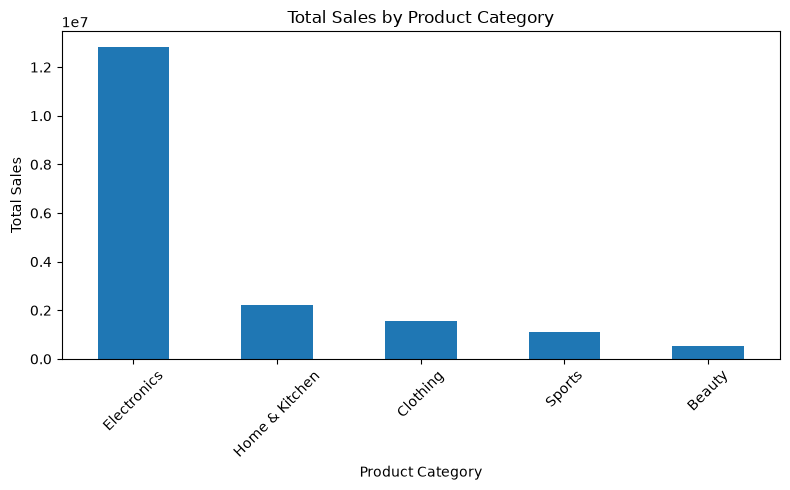

In [17]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
monthly_sales = df.groupby("Month_Name")["Total Amount"].sum()

print(monthly_sales)

Month_Name
April        1472770.65
August       2019721.46
December     1536328.72
February     1414329.48
January       945340.82
July         1814265.62
June         1915006.24
March        1129368.50
May          1722969.75
November     1208686.32
October      1397556.97
September    1664653.72
Name: Total Amount, dtype: float64


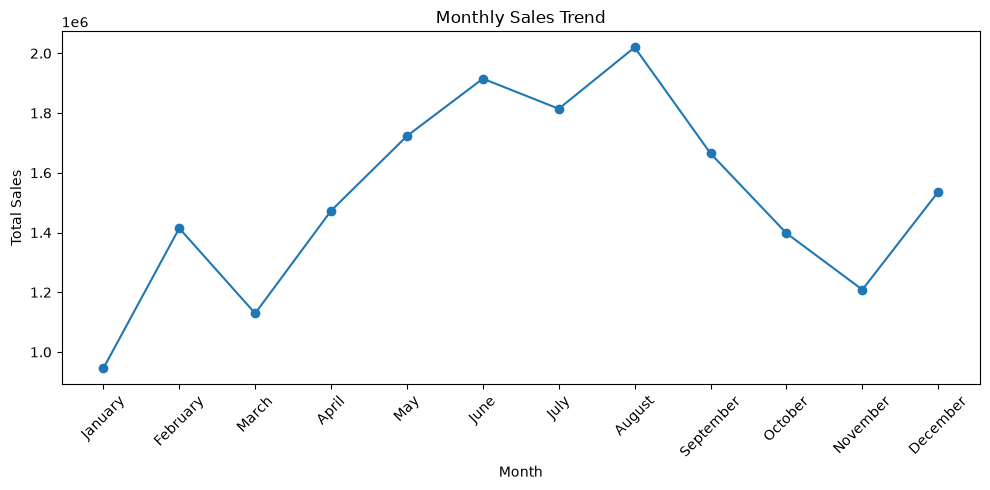

In [19]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month_Name")["Total Amount"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
category_sales

Product Category
Electronics       12831073.63
Home & Kitchen     2198395.57
Clothing           1545458.78
Sports             1118309.81
Beauty              547760.46
Name: Total Amount, dtype: float64

In [21]:
monthly_sales


Month_Name
January       945340.82
February     1414329.48
March        1129368.50
April        1472770.65
May          1722969.75
June         1915006.24
July         1814265.62
August       2019721.46
September    1664653.72
October      1397556.97
November     1208686.32
December     1536328.72
Name: Total Amount, dtype: float64

In [22]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Female    638
Male      574
Name: count, dtype: int64


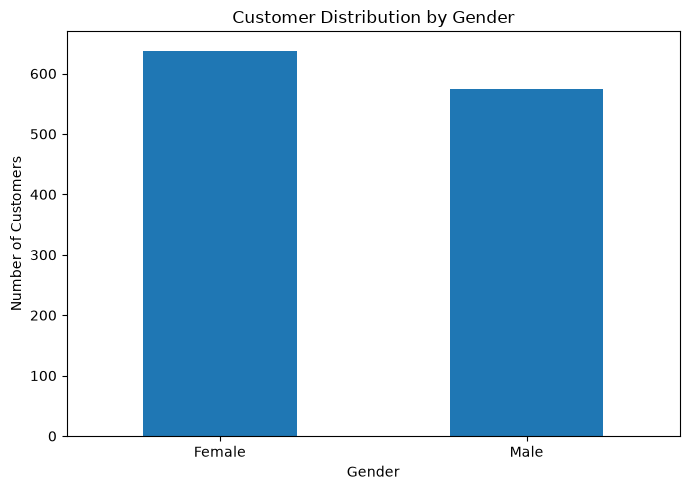

In [23]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
gender_sales = df.groupby("Gender")["Total Amount"].sum().sort_values(ascending=False)

print(gender_sales)

Gender
Female    9302922.03
Male      8938076.22
Name: Total Amount, dtype: float64


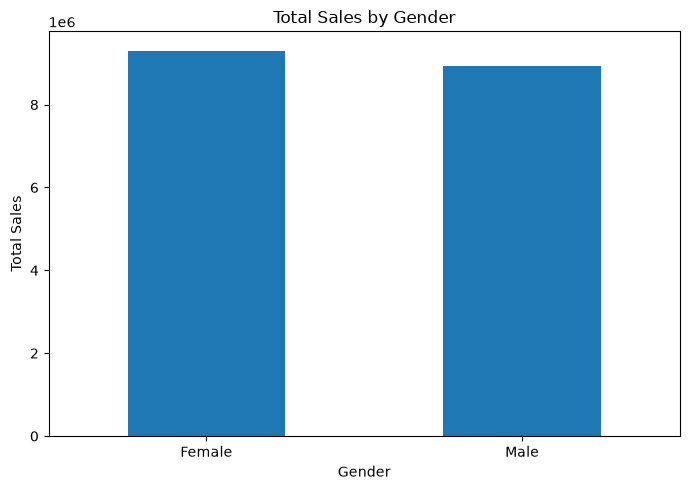

In [25]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer Age', 'Gender', 'City', 'Product Category', 'Product', 'Unit Price', 'Quantity', 'Discount (%)', 'Total Amount', 'Payment Method', 'Customer Rating', 'Year', 'Month', 'Month_Name', 'Day_of_Week']


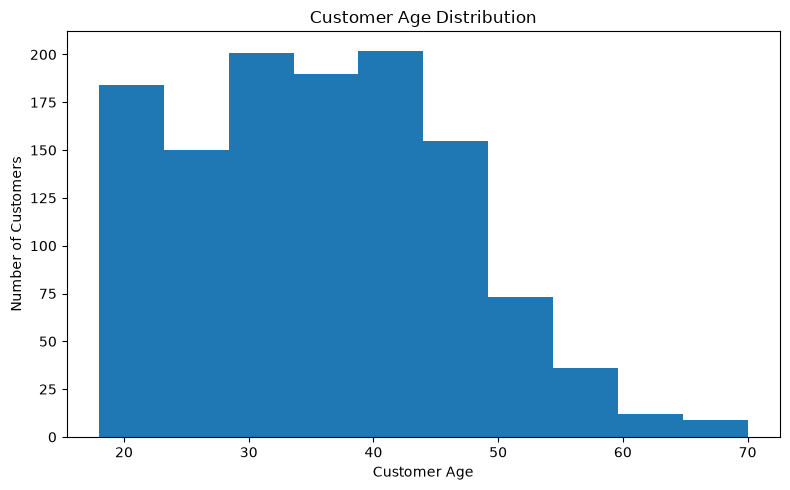

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(df["Customer Age"], bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

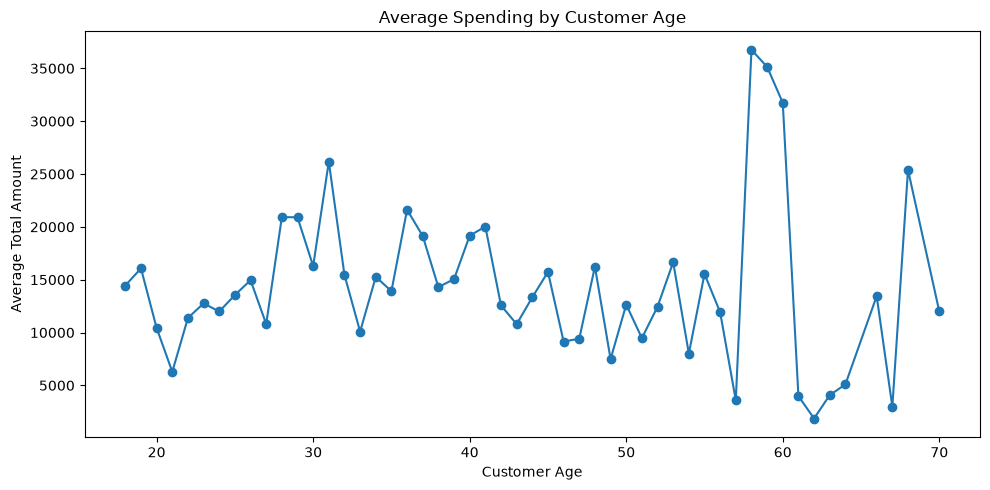

In [29]:
age_sales = df.groupby("Customer Age")["Total Amount"].mean()

plt.figure(figsize=(10, 5))

plt.plot(age_sales.index, age_sales.values, marker="o")

plt.title("Average Spending by Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Average Total Amount")
plt.tight_layout()
plt.show()

In [30]:
category_sales = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Product Category
Electronics       12831073.63
Home & Kitchen     2198395.57
Clothing           1545458.78
Sports             1118309.81
Beauty              547760.46
Name: Total Amount, dtype: float64


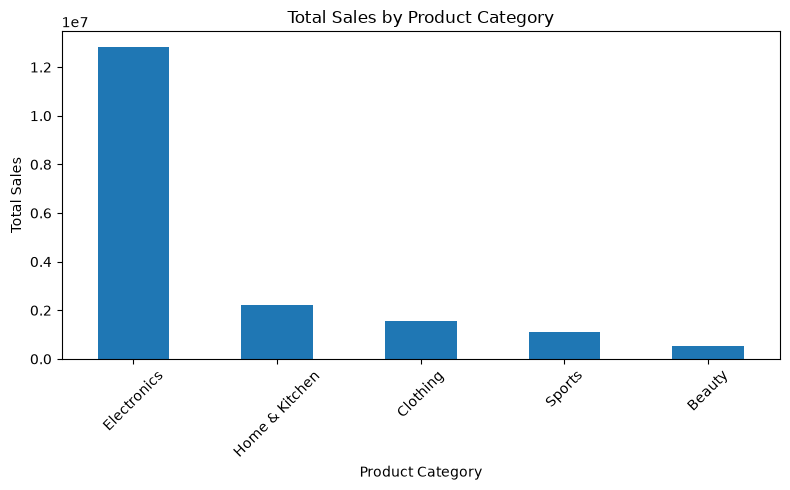

In [31]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
category_quantity = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity)

Product Category
Clothing          628
Electronics       573
Home & Kitchen    467
Beauty            378
Sports            290
Name: Quantity, dtype: int64


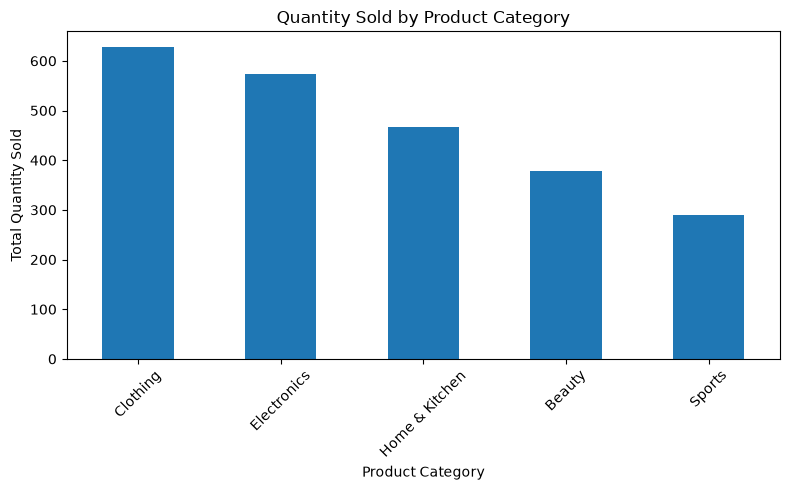

In [33]:
plt.figure(figsize=(8, 5))

category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
product_sales = (
    df.groupby("Product")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales.head(10))

Product
Smartphone           3258052.45
Smart Watch          2807960.14
Bluetooth Speaker    2741308.50
Wireless Earbuds     2440291.16
Laptop               1583461.38
Cookware Set          505895.76
Air Fryer             472251.00
Water Bottle          436437.45
Bedsheet              429236.58
Mixer Grinder         354574.78
Name: Total Amount, dtype: float64


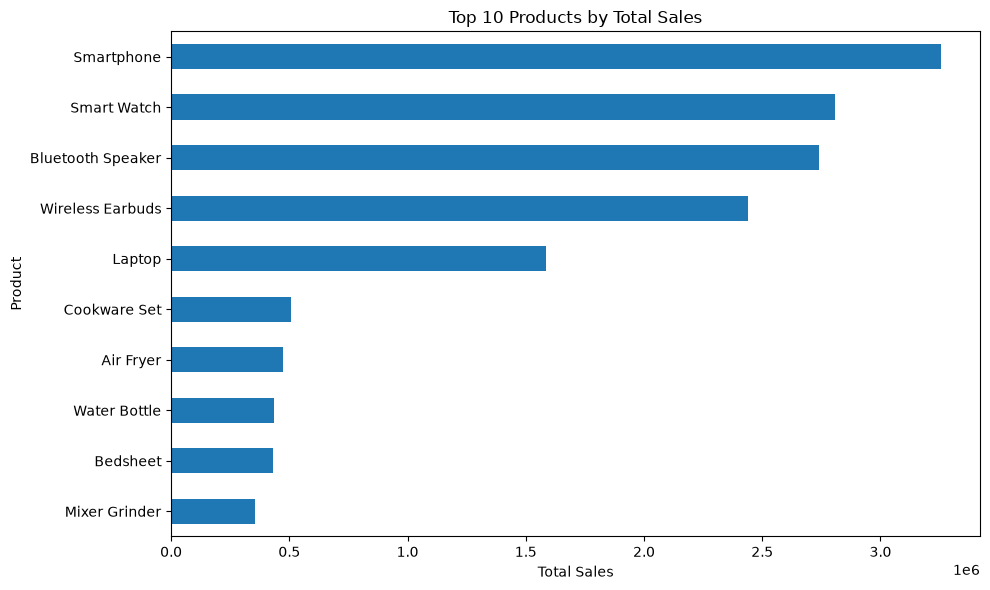

In [35]:
plt.figure(figsize=(10, 6))

product_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [36]:
product_quantity = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(product_quantity.head(10))

Product
Jeans                145
Sneakers             140
Smartphone           134
T-Shirt              130
Bluetooth Speaker    119
Smart Watch          118
Dress                118
Air Fryer            113
Wireless Earbuds     112
Moisturizer          104
Name: Quantity, dtype: int64


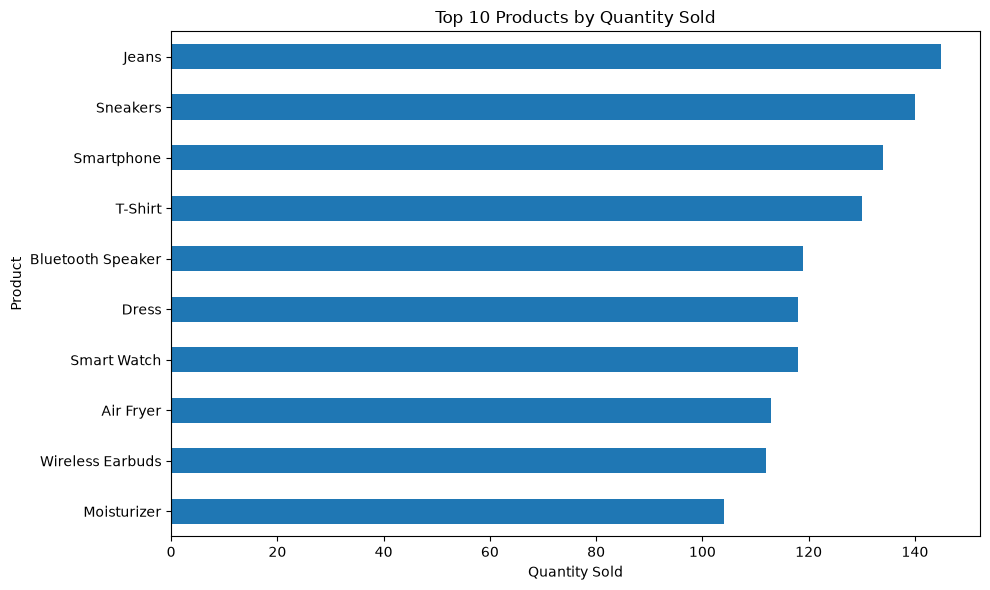

In [37]:
plt.figure(figsize=(10, 6))

product_quantity.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [38]:
category_sales

Product Category
Electronics       12831073.63
Home & Kitchen     2198395.57
Clothing           1545458.78
Sports             1118309.81
Beauty              547760.46
Name: Total Amount, dtype: float64

In [39]:
category_quantity

Product Category
Clothing          628
Electronics       573
Home & Kitchen    467
Beauty            378
Sports            290
Name: Quantity, dtype: int64

In [40]:
product_sales.head(10)

Product
Smartphone           3258052.45
Smart Watch          2807960.14
Bluetooth Speaker    2741308.50
Wireless Earbuds     2440291.16
Laptop               1583461.38
Cookware Set          505895.76
Air Fryer             472251.00
Water Bottle          436437.45
Bedsheet              429236.58
Mixer Grinder         354574.78
Name: Total Amount, dtype: float64

In [41]:
payment_counts = df["Payment Method"].value_counts()

print(payment_counts)

Payment Method
UPI            414
Credit Card    308
Debit Card     224
Net Banking    150
Cash           116
Name: count, dtype: int64


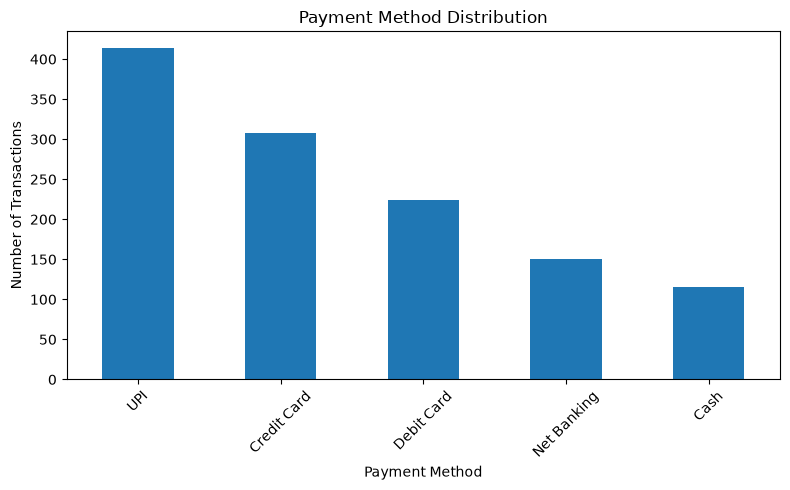

In [42]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Payment Method
UPI            5586381.84
Credit Card    4689102.91
Debit Card     3681948.11
Net Banking    2462302.36
Cash           1821263.03
Name: Total Amount, dtype: float64


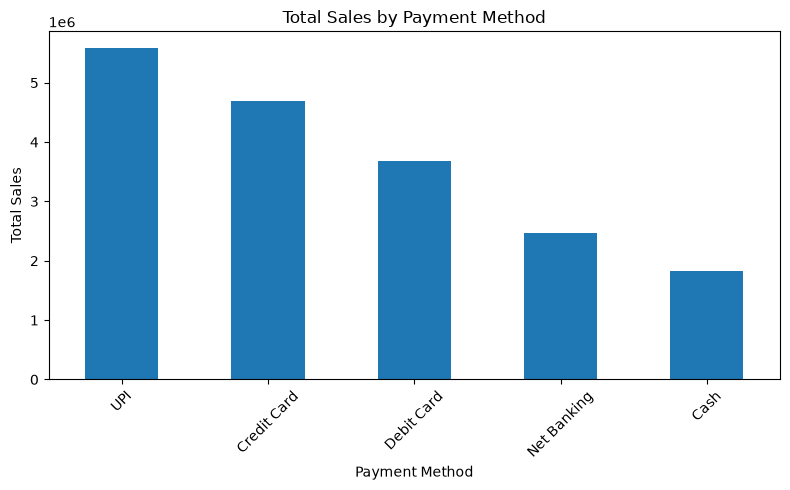

In [44]:
payment_sales = (
    df.groupby("Payment Method")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_sales)
plt.figure(figsize=(8, 5))

payment_sales.plot(kind="bar")

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer Rating
1.2      1
1.4      1
2.0      1
2.3      2
2.4      5
2.5      7
2.6     19
2.7      9
2.8     24
2.9     30
3.0     24
3.1     27
3.2     35
3.3     41
3.4     41
3.5     61
3.6     48
3.7     65
3.8     54
3.9     61
4.0     66
4.1     73
4.2     66
4.3     64
4.4     72
4.5     44
4.6     49
4.7     43
4.8     38
4.9     30
5.0    111
Name: count, dtype: int64


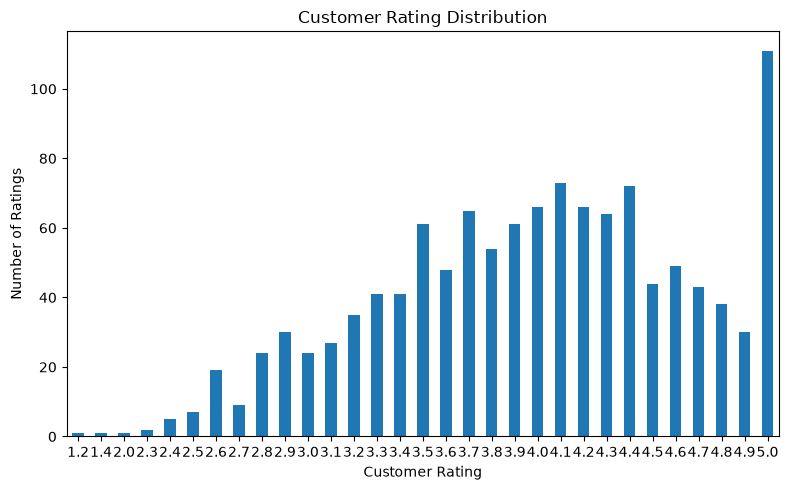

In [46]:
rating_counts = df["Customer Rating"].value_counts().sort_index()

print(rating_counts)
plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customer Rating
1.2    72182.610000
1.4     5588.050000
2.0     3866.230000
2.3     3728.015000
2.4    60803.708000
2.5    21269.681429
2.6     8154.877368
2.7    23266.261111
2.8    20358.028750
2.9    27685.808000
3.0    12402.477500
3.1    12027.203333
3.2    10387.687143
3.3    12381.391463
3.4    10723.418049
3.5    15690.158033
3.6    10784.822500
3.7    17368.190154
3.8    12655.755185
3.9    14116.933115
4.0    13799.965000
4.1    13218.680000
4.2    20290.144848
4.3    15212.638594
4.4    14905.014583
4.5    13420.389091
4.6     9862.795510
4.7    19296.727209
4.8    18154.735789
4.9    16153.503000
5.0    14362.941171
Name: Total Amount, dtype: float64


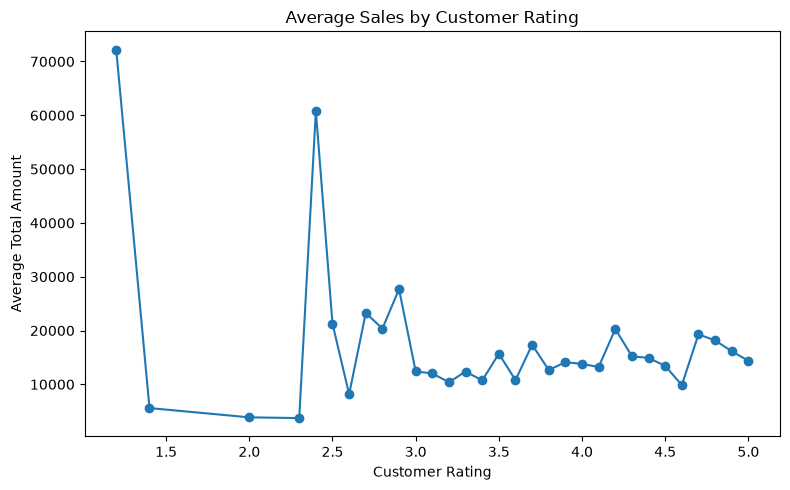

In [47]:
rating_sales = (
    df.groupby("Customer Rating")["Total Amount"]
    .mean()
    .sort_index()
)

print(rating_sales)
plt.figure(figsize=(8, 5))

plt.plot(rating_sales.index, rating_sales.values, marker="o")

plt.title("Average Sales by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Average Total Amount")
plt.tight_layout()
plt.show()

Average Discount: 7.013201320132013
Maximum Discount: 20.0


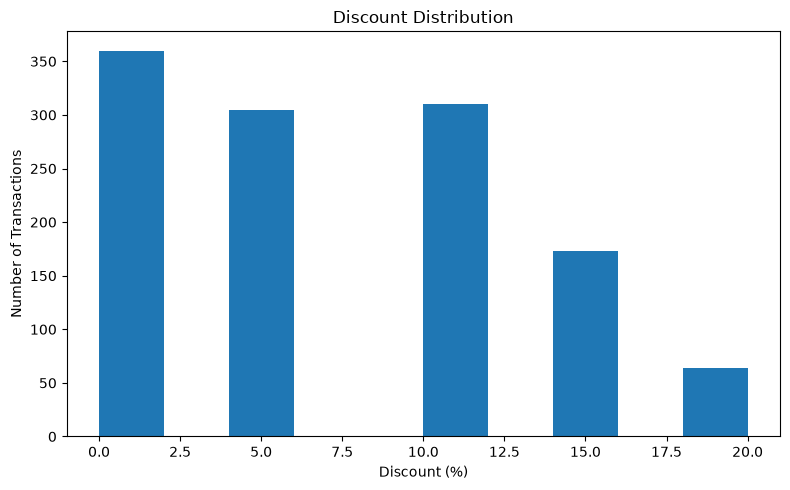

In [48]:
print("Average Discount:", df["Discount (%)"].mean())
print("Maximum Discount:", df["Discount (%)"].max())
plt.figure(figsize=(8, 5))

plt.hist(df["Discount (%)"], bins=10)

plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

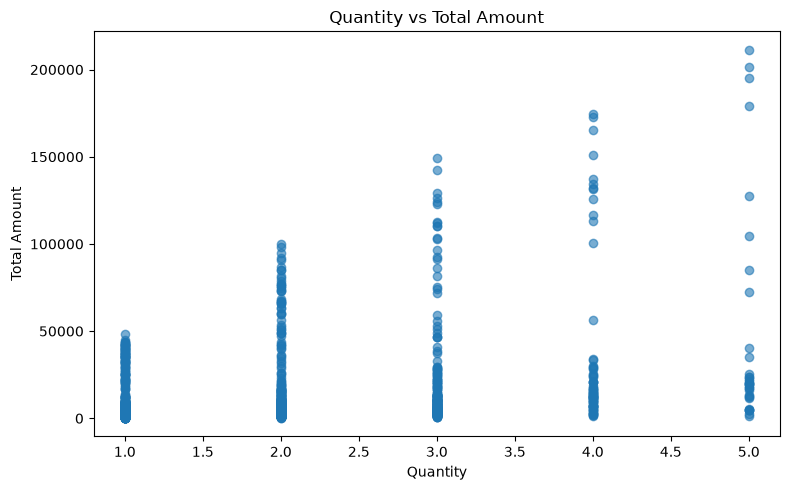

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["Total Amount"], alpha=0.6)

plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

In [50]:
numeric_columns = [
    "Customer Age",
    "Unit Price",
    "Quantity",
    "Discount (%)",
    "Total Amount",
    "Customer Rating"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

                 Customer Age  Unit Price  Quantity  Discount (%)  \
Customer Age         1.000000   -0.006088 -0.001389      0.026743   
Unit Price          -0.006088    1.000000 -0.007054     -0.041457   
Quantity            -0.001389   -0.007054  1.000000     -0.002292   
Discount (%)         0.026743   -0.041457 -0.002292      1.000000   
Total Amount        -0.001083    0.813948  0.332637     -0.074771   
Customer Rating     -0.009558    0.003653  0.014025     -0.011700   

                 Total Amount  Customer Rating  
Customer Age        -0.001083        -0.009558  
Unit Price           0.813948         0.003653  
Quantity             0.332637         0.014025  
Discount (%)        -0.074771        -0.011700  
Total Amount         1.000000        -0.021263  
Customer Rating     -0.021263         1.000000  


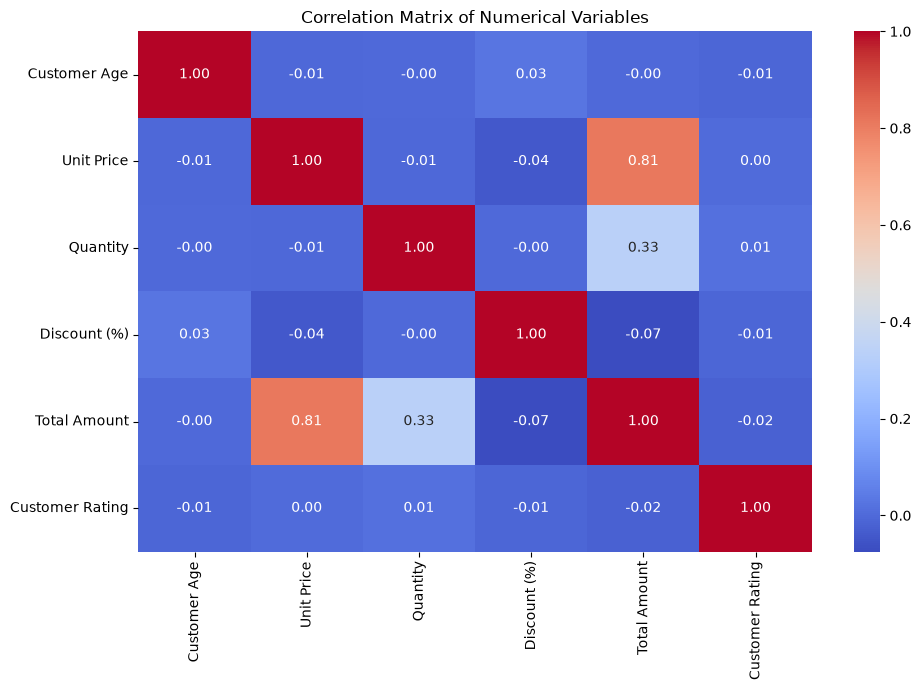

In [51]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

City
Kolkata      3216497.87
Pune         3111089.06
Mumbai       2495128.56
Bengaluru    2452641.07
Hyderabad    2364090.29
Delhi        2272929.89
Chennai      2180580.72
Name: Total Amount, dtype: float64


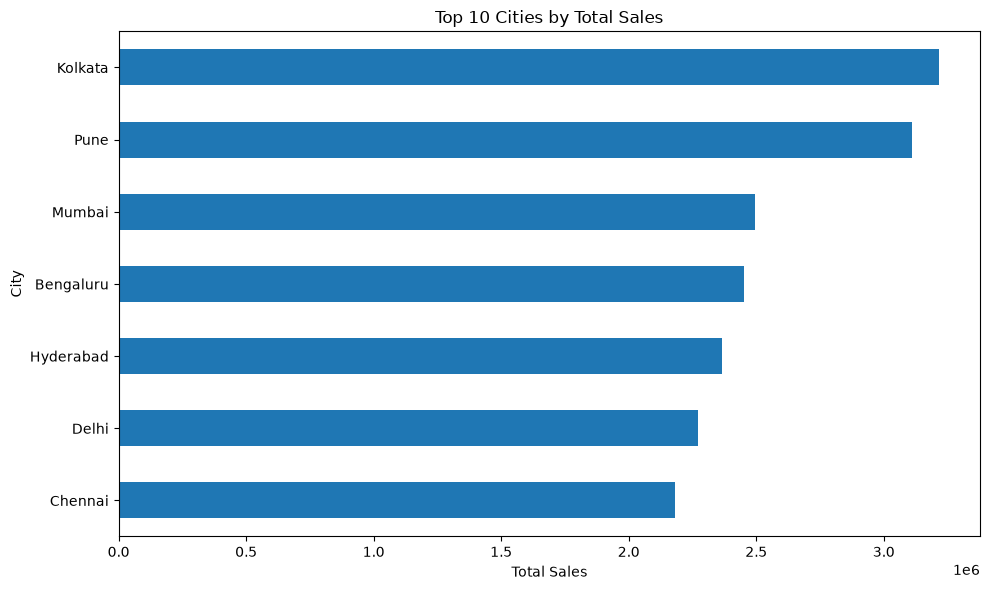

In [52]:
city_sales = (
    df.groupby("City")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales)
plt.figure(figsize=(10, 6))

city_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

Day_of_Week
Monday       3348444.77
Tuesday      3145608.29
Wednesday    2210039.66
Thursday     2552704.51
Friday       1953203.95
Saturday     2209843.10
Sunday       2821153.97
Name: Total Amount, dtype: float64


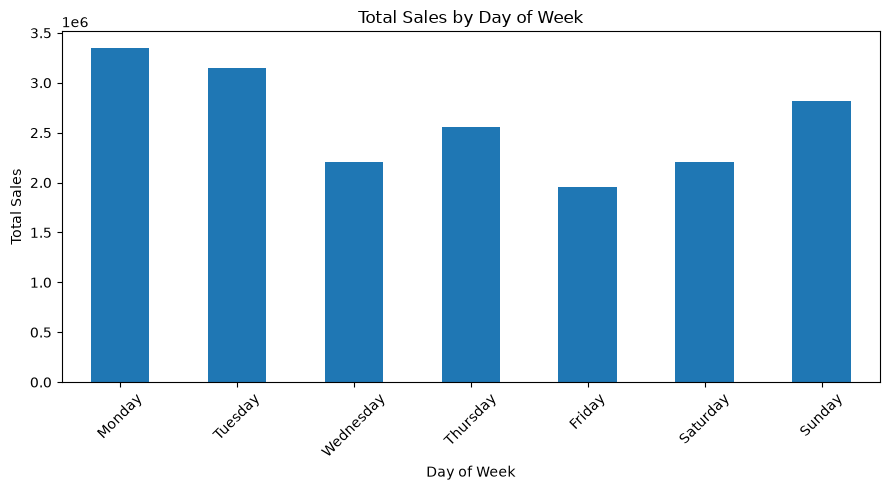

In [54]:
day_sales = (
    df.groupby("Day_of_Week")["Total Amount"]
    .sum()
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_sales = day_sales.reindex(day_order)

print(day_sales)
plt.figure(figsize=(9, 5))

day_sales.plot(kind="bar")

plt.title("Total Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (1212, 17)

Missing Values:
Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                6
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        0
Total Amount        0
Payment Method      0
Customer Rating     0
Year                0
Month               0
Month_Name          0
Day_of_Week         0
dtype: int64

Duplicate Rows: 12


In [56]:
print("===== KEY BUSINESS METRICS =====")

print("Total Sales:", df["Total Amount"].sum())
print("Average Transaction Value:", df["Total Amount"].mean())

print("\nBest Selling Category:")
print(category_sales.idxmax(), "->", category_sales.max())

print("\nLowest Selling Category:")
print(category_sales.idxmin(), "->", category_sales.min())

print("\nBest Payment Method by Sales:")
print(payment_sales.idxmax(), "->", payment_sales.max())

print("\nHighest Sales Month:")
print(monthly_sales.idxmax(), "->", monthly_sales.max())

print("\nLowest Sales Month:")
print(monthly_sales.idxmin(), "->", monthly_sales.min())

print("\nBest Sales Day:")
print(day_sales.idxmax(), "->", day_sales.max())

print("\nTop City:")
print(city_sales.idxmax(), "->", city_sales.max())

print("\nTop Product:")
print(product_sales.idxmax(), "->", product_sales.max())

===== KEY BUSINESS METRICS =====
Total Sales: 18240998.25
Average Transaction Value: 15050.32858910891

Best Selling Category:
Electronics -> 12831073.63

Lowest Selling Category:
Beauty -> 547760.46

Best Payment Method by Sales:
UPI -> 5586381.84

Highest Sales Month:
August -> 2019721.46

Lowest Sales Month:
January -> 945340.8200000001

Best Sales Day:
Monday -> 3348444.77

Top City:
Kolkata -> 3216497.87

Top Product:
Smartphone -> 3258052.45


In [57]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Average Transaction Value",
        "Highest Sales Month",
        "Lowest Sales Month",
        "Best Product Category",
        "Best Payment Method",
        "Top City",
        "Top Product"
    ],
    "Result": [
        df["Total Amount"].sum(),
        df["Total Amount"].mean(),
        monthly_sales.idxmax(),
        monthly_sales.idxmin(),
        category_sales.idxmax(),
        payment_sales.idxmax(),
        city_sales.idxmax(),
        product_sales.idxmax()
    ]
})

summary

,Metric,Result
0,Total Sales,18240998.25
1,Average Transaction Value,15050.328589
2,Highest Sales Month,August
3,Lowest Sales Month,January
4,Best Product Category,Electronics
5,Best Payment Method,UPI
6,Top City,Kolkata
7,Top Product,Smartphone


## Business Recommendations

1. **Strengthen the Electronics category**
   - Prioritize inventory and promotional efforts for high-performing electronic products.

2. **Promote lower-performing categories**
   - Consider targeted discounts and promotional campaigns to improve Beauty category sales.

3. **Prepare for high-sales periods**
   - August recorded the highest monthly sales, so inventory planning should account for higher demand.

4. **Improve low-sales periods**
   - January recorded the lowest monthly sales. Seasonal promotions could help improve weaker periods.

5. **Support popular payment methods**
   - UPI generated the highest sales among payment methods, so maintaining a convenient UPI experience is important.

6. **Focus on high-performing locations**
   - Kolkata generated the highest city-level sales. Location-specific marketing can help maintain strong performance.

7. **Monitor high-performing products**
   - Smartphone was the top-performing product. Maintaining sufficient stock can help avoid missed sales opportunities.

8. **Use sales trends for planning**
   - Monthly and day-of-week patterns can support better inventory, staffing, and promotional decisions.

## Conclusion

The Retail Sales Analysis project successfully explored retail transaction data to identify important patterns in sales performance, customers, products, payment methods, locations, and time periods.

The analysis found that Electronics was the strongest-performing product category, while Smartphone was the top-performing individual product. UPI generated the highest sales among the payment methods, and Kolkata recorded the highest city-level sales. August had the highest monthly sales, whereas January recorded the lowest monthly sales.

Through data cleaning, descriptive statistics, exploratory analysis, and visualizations, the project transformed raw retail transaction data into meaningful business insights. These findings can support better inventory management, promotional planning, customer targeting, and sales strategies.

Overall, this project demonstrates how Exploratory Data Analysis (EDA) can be used to understand retail sales patterns and support data-driven business decision-making.
